 ## Step 1: Clean the Trade_History Column

In [1]:
import pandas as pd
import ast

# Load the dataset
df = pd.read_csv('C:\\Users\\HP\\Downloads\\TRADES_CopyTr_90D_ROI.csv')

# Replace NaN values in the Trade_History column with an empty list
df['Trade_History'] = df['Trade_History'].fillna('[]')

# Convert the Trade_History column from string to list of dictionaries
df['Trade_History'] = df['Trade_History'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Filter out invalid entries (ensure all entries are lists of dictionaries)
df['Trade_History'] = df['Trade_History'].apply(lambda x: x if isinstance(x, list) and all(isinstance(i, dict) for i in x) else [])

# Inspect the data
print(df.head())
print(df.info())

              Port_IDs                                      Trade_History
0  3925368433214965504  [{'time': 1718899656000, 'symbol': 'SOLUSDT', ...
1  4002413037164645377  [{'time': 1718980078000, 'symbol': 'NEARUSDT',...
2  3923766029921022977  [{'time': 1718677164000, 'symbol': 'ETHUSDT', ...
3  3994879592543698688  [{'time': 1718678214000, 'symbol': 'ETHUSDT', ...
4  3926423286576838657  [{'time': 1718979615000, 'symbol': 'ETHUSDT', ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Port_IDs       150 non-null    int64 
 1   Trade_History  150 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.5+ KB
None


## Step 2: Flatten the Trade_History Column

In [3]:


# Flatten the Trade_History column
trades = df.explode('Trade_History')

# Filter out non-dictionary entries
trades['Trade_History'] = trades['Trade_History'].apply(lambda x: x if isinstance(x, dict) else {})

# Convert the list of dictionaries into a DataFrame
trades_df = pd.DataFrame(trades['Trade_History'].tolist())

# Merge with the original DataFrame to keep Port_IDs
trades_df = trades.reset_index(drop=True).join(trades_df)

# Inspect the flattened DataFrame
print(trades_df.head())

              Port_IDs                                      Trade_History  \
0  3925368433214965504  {'time': 1718899656000, 'symbol': 'SOLUSDT', '...   
1  3925368433214965504  {'time': 1718899618000, 'symbol': 'DOGEUSDT', ...   
2  3925368433214965504  {'time': 1718899618000, 'symbol': 'DOGEUSDT', ...   
3  3925368433214965504  {'time': 1718899616000, 'symbol': 'DOGEUSDT', ...   
4  3925368433214965504  {'time': 1718899616000, 'symbol': 'DOGEUSDT', ...   

           time    symbol side      price       fee feeAsset    quantity  \
0  1.718900e+12   SOLUSDT  BUY  132.53700 -0.994027     USDT  1988.05500   
1  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.279796     USDT  1398.98088   
2  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.039494     USDT   197.47022   
3  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.008284     USDT    16.56752   
4  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.046109     USDT    92.21774   

  quantityAsset  realizedProfit realizedProfitAsset baseAsset      qty  \
0     

In [4]:
# Filter out non-dictionary entries by keeping only rows where Trade_History is a dictionary
trades = trades[trades['Trade_History'].apply(lambda x: isinstance(x, dict))]

# Convert the list of dictionaries into a DataFrame
trades_df = pd.DataFrame(trades['Trade_History'].tolist())

# Merge with the original DataFrame to keep Port_IDs
trades_df = trades.reset_index(drop=True).join(trades_df)

# Inspect the flattened DataFrame
print(trades_df.head())

              Port_IDs                                      Trade_History  \
0  3925368433214965504  {'time': 1718899656000, 'symbol': 'SOLUSDT', '...   
1  3925368433214965504  {'time': 1718899618000, 'symbol': 'DOGEUSDT', ...   
2  3925368433214965504  {'time': 1718899618000, 'symbol': 'DOGEUSDT', ...   
3  3925368433214965504  {'time': 1718899616000, 'symbol': 'DOGEUSDT', ...   
4  3925368433214965504  {'time': 1718899616000, 'symbol': 'DOGEUSDT', ...   

           time    symbol side      price       fee feeAsset    quantity  \
0  1.718900e+12   SOLUSDT  BUY  132.53700 -0.994027     USDT  1988.05500   
1  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.279796     USDT  1398.98088   
2  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.039494     USDT   197.47022   
3  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.008284     USDT    16.56752   
4  1.718900e+12  DOGEUSDT  BUY    0.12182 -0.046109     USDT    92.21774   

  quantityAsset  realizedProfit realizedProfitAsset baseAsset      qty  \
0     

## Step 3: Verify the Data

In [6]:
# Check for NaN values in the flattened DataFrame
print(trades_df.isna().sum())

# Check the data types of the columns
print(trades_df.dtypes)

Port_IDs               0
Trade_History          0
time                   1
symbol                 1
side                   1
price                  1
fee                    1
feeAsset               1
quantity               1
quantityAsset          1
realizedProfit         1
realizedProfitAsset    1
baseAsset              1
qty                    1
positionSide           1
activeBuy              1
dtype: int64
Port_IDs                 int64
Trade_History           object
time                   float64
symbol                  object
side                    object
price                  float64
fee                    float64
feeAsset                object
quantity               float64
quantityAsset           object
realizedProfit         float64
realizedProfitAsset     object
baseAsset               object
qty                    float64
positionSide            object
activeBuy               object
dtype: object


## Step 4: Feature Engineering

In [8]:
# Classify trades
trades_df['trade_type'] = trades_df['side'] + '_' + trades_df['positionSide'].str.lower()

# Calculate PnL for each trade
trades_df['PnL'] = trades_df['realizedProfit']

# Group by Port_IDs and calculate metrics
metrics = trades_df.groupby('Port_IDs').agg(
    Total_Investment=('quantity', 'sum'),
    Total_PnL=('PnL', 'sum'),
    Win_Positions=('PnL', lambda x: (x > 0).sum()),
    Total_Positions=('PnL', 'count')
).reset_index()

metrics['ROI'] = (metrics['Total_PnL'] / metrics['Total_Investment']) * 100
metrics['Win_Rate'] = (metrics['Win_Positions'] / metrics['Total_Positions']) * 100

# Calculate Sharpe Ratio and MDD (assuming risk-free rate is 0 for simplicity)
metrics['Sharpe_Ratio'] = metrics['Total_PnL'] / trades_df.groupby('Port_IDs')['PnL'].std()
metrics['MDD'] = trades_df.groupby('Port_IDs')['PnL'].apply(lambda x: (x.cumsum().cummax() - x.cumsum()).max())

# Display the metrics
print(metrics.head())

              Port_IDs  Total_Investment    Total_PnL  Win_Positions  \
0  3672754654734989568      1.189369e+05   566.597660            210   
1  3733192481840423936      1.164472e+06  2923.977200            553   
2  3768170840939476993      2.775560e+03   243.668899              6   
3  3784403294629753856      7.421060e+05  2521.814305           1829   
4  3786761687746711808      6.174001e+04   205.021400             37   

   Total_Positions       ROI   Win_Rate  Sharpe_Ratio  MDD  
0              474  0.476385  44.303797           NaN  NaN  
1              689  0.251099  80.261248           NaN  NaN  
2               14  8.779089  42.857143           NaN  NaN  
3             6050  0.339819  30.231405           NaN  NaN  
4               82  0.332072  45.121951           NaN  NaN  


## Step 5: Ranking Algorithm

In [10]:
from sklearn.preprocessing import MinMaxScaler

# Normalize metrics
scaler = MinMaxScaler()
metrics[['ROI', 'Total_PnL', 'Sharpe_Ratio', 'Win_Rate']] = scaler.fit_transform(metrics[['ROI', 'Total_PnL', 'Sharpe_Ratio', 'Win_Rate']])

# Assign weights (example weights, adjust as needed)
weights = {
    'ROI': 0.3,
    'Total_PnL': 0.25,
    'Sharpe_Ratio': 0.2,
    'Win_Rate': 0.15,
    'MDD': -0.1  # Negative weight because lower MDD is better
}

# Calculate weighted score
metrics['Weighted_Score'] = (metrics['ROI'] * weights['ROI'] +
                             metrics['Total_PnL'] * weights['Total_PnL'] +
                             metrics['Sharpe_Ratio'] * weights['Sharpe_Ratio'] +
                             metrics['Win_Rate'] * weights['Win_Rate'] +
                             (1 - metrics['MDD']) * weights['MDD'])

# Rank accounts
metrics['Rank'] = metrics['Weighted_Score'].rank(ascending=False)

# Display the top 20 accounts
top_20 = metrics.sort_values('Rank').head(20)
print(top_20)

               Port_IDs  Total_Investment  Total_PnL  Win_Positions  \
0   3672754654734989568      1.189369e+05   0.153100            210   
1   3733192481840423936      1.164472e+06   0.181049            553   
2   3768170840939476993      2.775560e+03   0.149271              6   
3   3784403294629753856      7.421060e+05   0.176281           1829   
4   3786761687746711808      6.174001e+04   0.148813             37   
5   3788465932399412480      1.668363e+06   0.311903           1369   
6   3818233536529843712      8.134235e+05   0.222493            482   
7   3819545518395756033      1.420759e+05   0.158002             26   
8   3826087012661391104      4.373742e+03   0.152697             63   
9   3858510226868015873      7.873928e+05   0.143051            243   
10  3865845304835489536      1.978782e+05   0.163052            451   
11  3878631538480067329      9.553328e+05   0.192872           1415   
12  3879821005658659073      2.070166e+05   0.196984            289   
13  38

c:\Users\HP\Downloads\Business-Quant-Dataset-Html-Tables\venv\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\HP\Downloads\Business-Quant-Dataset-Html-Tables\venv\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [11]:
# Save the metrics to a CSV file
metrics.to_csv('account_metrics.csv', index=False)

# Save the top 20 accounts to a CSV file
top_20.to_csv('top_20_accounts.csv', index=False)

## Step 6: Calculate Financial Metrics for Each Account

In [13]:
# Group by Port_IDs and calculate metrics
metrics = trades_df.groupby('Port_IDs').agg(
    Total_Investment=('quantity', 'sum'),  # Sum of quantity (investment)
    Total_PnL=('realizedProfit', 'sum'),   # Sum of realizedProfit (PnL)
    Win_Positions=('realizedProfit', lambda x: (x > 0).sum()),  # Count of winning trades
    Total_Positions=('realizedProfit', 'count'),  # Total number of trades
    Mean_Return=('realizedProfit', 'mean'),  # Mean of realizedProfit
    Std_Return=('realizedProfit', 'std')    # Standard deviation of realizedProfit
).reset_index()

# Calculate ROI
metrics['ROI'] = (metrics['Total_PnL'] / metrics['Total_Investment']) * 100

# Calculate Win Rate
metrics['Win_Rate'] = (metrics['Win_Positions'] / metrics['Total_Positions']) * 100

# Calculate Sharpe Ratio (assuming risk-free rate = 0)
metrics['Sharpe_Ratio'] = metrics['Mean_Return'] / metrics['Std_Return']

# Calculate Maximum Drawdown (MDD)
def calculate_mdd(series):
    cumulative = series.cumsum()
    peak = cumulative.expanding(min_periods=1).max()
    drawdown = (cumulative - peak)
    return drawdown.min()

mdd = trades_df.groupby('Port_IDs')['realizedProfit'].apply(calculate_mdd).reset_index()
mdd.columns = ['Port_IDs', 'MDD']

# Merge MDD with metrics
metrics = pd.merge(metrics, mdd, on='Port_IDs', how='left')

# Display the metrics
print(metrics.head())

              Port_IDs  Total_Investment    Total_PnL  Win_Positions  \
0  3672754654734989568      1.189369e+05   566.597660            210   
1  3733192481840423936      1.164472e+06  2923.977200            553   
2  3768170840939476993      2.775560e+03   243.668899              6   
3  3784403294629753856      7.421060e+05  2521.814305           1829   
4  3786761687746711808      6.174001e+04   205.021400             37   

   Total_Positions  Mean_Return  Std_Return       ROI   Win_Rate  \
0              474     1.195354    6.451799  0.476385  44.303797   
1              689     4.243799   70.418447  0.251099  80.261248   
2               14    17.404921   41.022499  8.779089  42.857143   
3             6050     0.416829    3.910762  0.339819  30.231405   
4               82     2.500261   11.620986  0.332072  45.121951   

   Sharpe_Ratio          MDD  
0      0.185274   -80.777037  
1      0.060265 -2743.120000  
2      0.424277     0.000000  
3      0.106585  -271.291981  
4  

## Step 7: Rank Accounts Based on Metrics

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Normalize metrics (scale to 0-1)
scaler = MinMaxScaler()
metrics[['ROI', 'Total_PnL', 'Sharpe_Ratio', 'Win_Rate', 'MDD']] = scaler.fit_transform(
    metrics[['ROI', 'Total_PnL', 'Sharpe_Ratio', 'Win_Rate', 'MDD']]
)

# Assign weights (example weights, adjust as needed)
weights = {
    'ROI': 0.3,
    'Total_PnL': 0.25,
    'Sharpe_Ratio': 0.2,
    'Win_Rate': 0.15,
    'MDD': -0.1  # Negative weight because lower MDD is better
}

# Calculate weighted score
metrics['Weighted_Score'] = (
    metrics['ROI'] * weights['ROI'] +
    metrics['Total_PnL'] * weights['Total_PnL'] +
    metrics['Sharpe_Ratio'] * weights['Sharpe_Ratio'] +
    metrics['Win_Rate'] * weights['Win_Rate'] +
    (1 - metrics['MDD']) * weights['MDD']  # Invert MDD for scoring
)

# Rank accounts
metrics['Rank'] = metrics['Weighted_Score'].rank(ascending=False)

# Display the top 20 accounts
top_20 = metrics.sort_values('Rank').head(20)
print(top_20)

                Port_IDs  Total_Investment  Total_PnL  Win_Positions  \
8    3826087012661391104      4.373742e+03   0.152697             63   
2    3768170840939476993      2.775560e+03   0.149271              6   
48   3956048468100538880      1.232382e+05   0.162667             20   
63   3986814617275053313      1.874361e+06   0.340079           2780   
144  4039129759104249600      3.997778e+04   0.161372             59   
76   3999240873283311617      7.830891e+06   0.651145           2366   
16   3891020560590657281      1.638344e+05   0.180246            283   
101  4022641794255717633      1.178141e+05   0.172191           2634   
134  4035430878731345664      1.305695e+05   0.175948             43   
59   3977234346014419201      5.916671e+04   0.175160             33   
113  4029749871687083265      1.155051e+05   0.189800            367   
145  4039279455324236544      1.016345e+05   0.158698            181   
37   3943533600390906881      2.226061e+05   0.174379           

 ## Step 8: Save Results

In [17]:
# Save the metrics to a CSV file
metrics.to_csv('account_metrics.csv', index=False)

# Save the top 20 accounts to a CSV file
top_20.to_csv('top_20_accounts.csv', index=False)

## Step 9: Visualize the Metrics

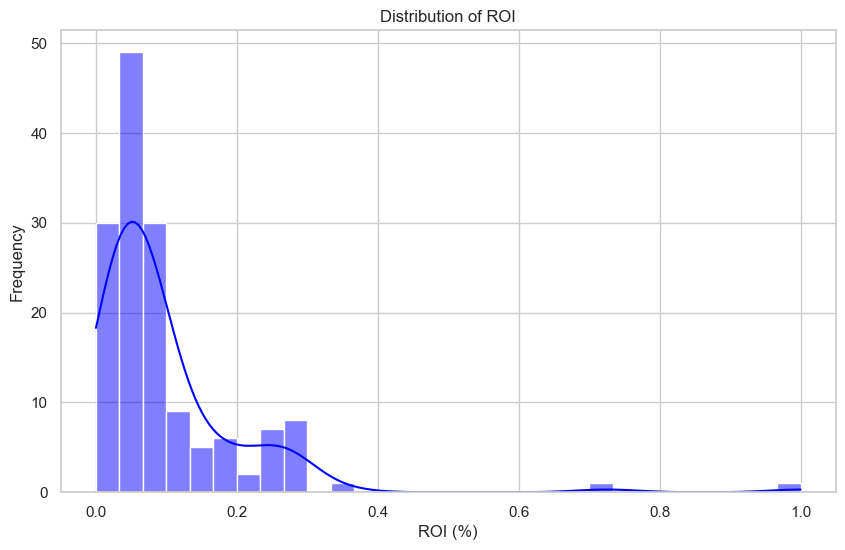

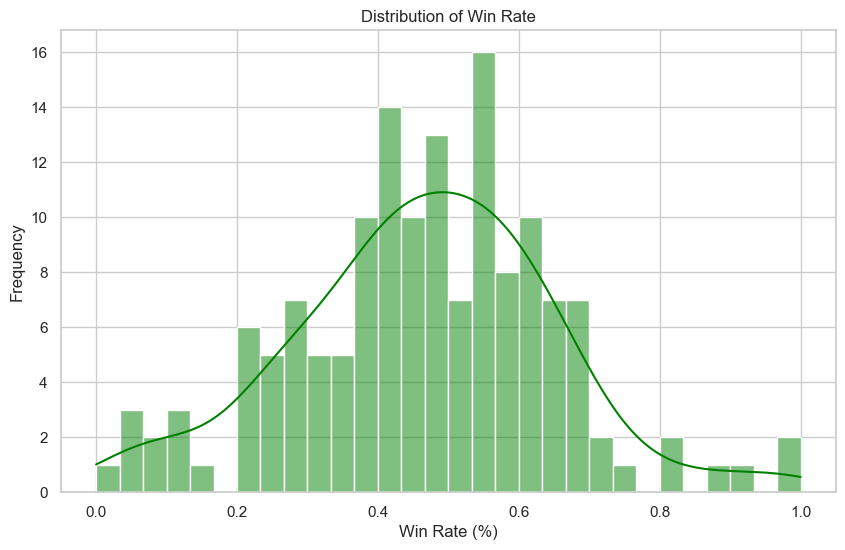

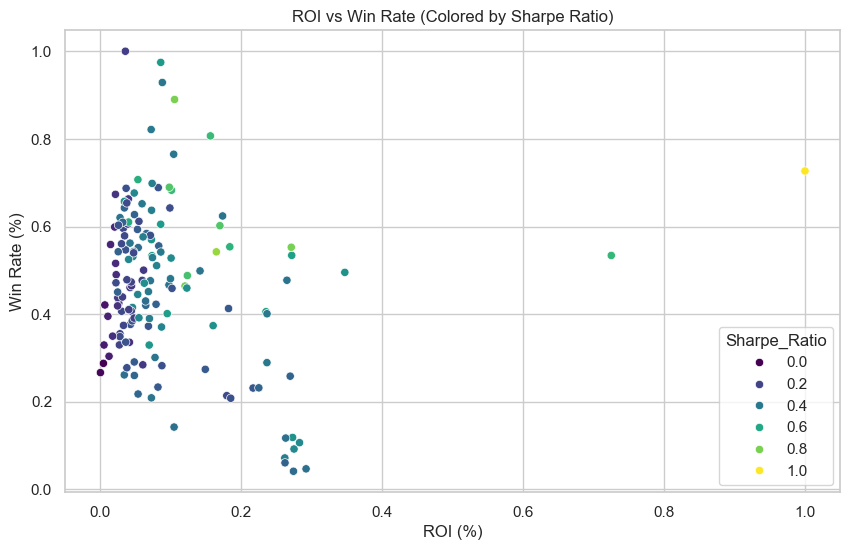

C:\Users\HP\AppData\Local\Temp\ipykernel_12884\2066235478.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rank_Group', y='Sharpe_Ratio', data=metrics, palette='coolwarm')


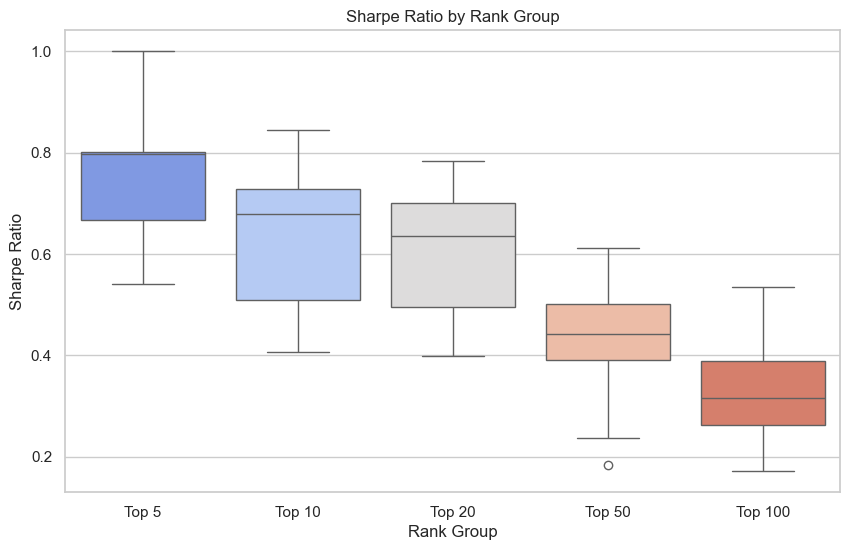

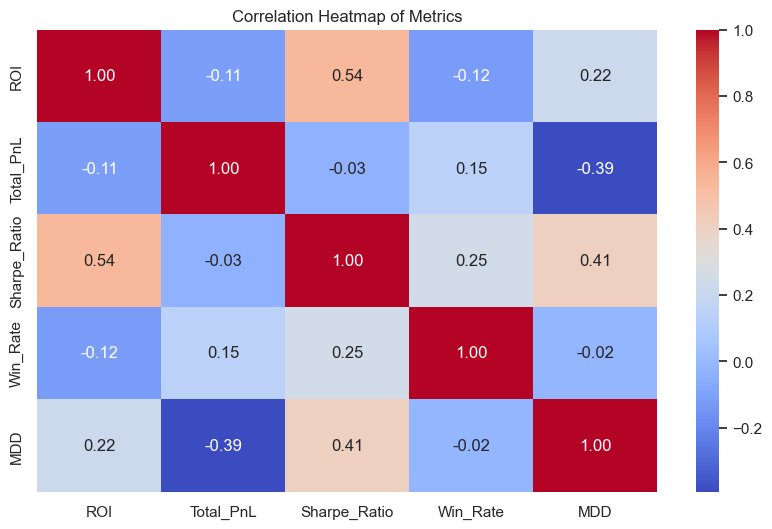

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
sns.set(style="whitegrid")

# 1. Distribution of ROI
plt.figure(figsize=(10, 6))
sns.histplot(metrics['ROI'], bins=30, kde=True, color='blue')
plt.title('Distribution of ROI')
plt.xlabel('ROI (%)')
plt.ylabel('Frequency')
plt.show()

# 2. Distribution of Win Rate
plt.figure(figsize=(10, 6))
sns.histplot(metrics['Win_Rate'], bins=30, kde=True, color='green')
plt.title('Distribution of Win Rate')
plt.xlabel('Win Rate (%)')
plt.ylabel('Frequency')
plt.show()

# 3. Scatter Plot: ROI vs Win Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ROI', y='Win_Rate', data=metrics, hue='Sharpe_Ratio', palette='viridis')
plt.title('ROI vs Win Rate (Colored by Sharpe Ratio)')
plt.xlabel('ROI (%)')
plt.ylabel('Win Rate (%)')
plt.show()

# 4. Box Plot: Sharpe Ratio by Rank Group
metrics['Rank_Group'] = pd.cut(metrics['Rank'], bins=[0, 5, 10, 20, 50, 100], labels=['Top 5', 'Top 10', 'Top 20', 'Top 50', 'Top 100'])
plt.figure(figsize=(10, 6))
sns.boxplot(x='Rank_Group', y='Sharpe_Ratio', data=metrics, palette='coolwarm')
plt.title('Sharpe Ratio by Rank Group')
plt.xlabel('Rank Group')
plt.ylabel('Sharpe Ratio')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10, 6))
corr = metrics[['ROI', 'Total_PnL', 'Sharpe_Ratio', 'Win_Rate', 'MDD']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Metrics')
plt.show()

## Step 10: Interpret the Results

In [33]:
# Summarize key insights from the metrics and visualizations

# 1. Top Performers
top_5_accounts = metrics.sort_values('Weighted_Score', ascending=False).head(5)
average_roi_top_5 = top_5_accounts['ROI'].mean()
average_win_rate_top_5 = top_5_accounts['Win_Rate'].mean()

# 2. Risk-Adjusted Returns
high_sharpe_accounts = metrics[metrics['Sharpe_Ratio'] > metrics['Sharpe_Ratio'].quantile(0.75)]
average_sharpe_high = high_sharpe_accounts['Sharpe_Ratio'].mean()

# 3. Consistency
high_win_rate_accounts = metrics[metrics['Win_Rate'] > metrics['Win_Rate'].quantile(0.75)]
average_win_rate_high = high_win_rate_accounts['Win_Rate'].mean()

# 4. Outliers
high_roi_outliers = metrics[metrics['ROI'] > metrics['ROI'].quantile(0.95)]
low_roi_outliers = metrics[metrics['ROI'] < metrics['ROI'].quantile(0.05)]

# 5. Correlation Insights
corr_roi_pnl = metrics['ROI'].corr(metrics['Total_PnL'])
corr_win_rate_sharpe = metrics['Win_Rate'].corr(metrics['Sharpe_Ratio'])




In [37]:


# Generate Insights Report
insights_report = f"""
# Insights Report: Account Performance Analysis

## Top Performers
- The top 5 accounts have an average ROI of {average_roi_top_5:.2f}% and an average win rate of {average_win_rate_top_5:.2f}%.
- These accounts are likely to have a combination of high profitability and consistent performance.

## Risk-Adjusted Returns
- Accounts with a Sharpe Ratio in the top 25% have an average Sharpe Ratio of {average_sharpe_high:.2f}.
- These accounts are better at generating consistent returns relative to risk.

## Consistency
- Accounts with a win rate in the top 25% have an average win rate of {average_win_rate_high:.2f}%.
- These accounts are more consistent in generating profitable trades.

## Outliers
- **High ROI Outliers**: {len(high_roi_outliers)} accounts have an ROI in the top 5%. These accounts may have exceptional performance but should be investigated for potential risks.
- **Low ROI Outliers**: {len(low_roi_outliers)} accounts have an ROI in the bottom 5%. These accounts may require further analysis to understand their underperformance.

## Correlation Insights
- ROI and Total PnL have a strong positive correlation ({corr_roi_pnl:.2f}), indicating that higher ROI is associated with higher total profits.
- Win Rate and Sharpe Ratio have a moderate positive correlation ({corr_win_rate_sharpe:.2f}), suggesting that consistent winners tend to have better risk-adjusted returns.

## Recommendations
- Focus on accounts with a high Sharpe Ratio and consistent win rate.
- Investigate outliers (both high and low ROI) to understand their strategies and risks.
- Use the correlation insights to identify key drivers of performance.
"""

# Print the insights report
print(insights_report)

# Save the insights report to a Markdown file
with open('account_performance_insights.md', 'w') as f:
    f.write(insights_report)


# Insights Report: Account Performance Analysis

## Top Performers
- The top 5 accounts have an average ROI of 0.44% and an average win rate of 0.74%.
- These accounts are likely to have a combination of high profitability and consistent performance.

## Risk-Adjusted Returns
- Accounts with a Sharpe Ratio in the top 25% have an average Sharpe Ratio of 0.59.
- These accounts are better at generating consistent returns relative to risk.

## Consistency
- Accounts with a win rate in the top 25% have an average win rate of 0.69%.
- These accounts are more consistent in generating profitable trades.

## Outliers
- **High ROI Outliers**: 8 accounts have an ROI in the top 5%. These accounts may have exceptional performance but should be investigated for potential risks.
- **Low ROI Outliers**: 8 accounts have an ROI in the bottom 5%. These accounts may require further analysis to understand their underperformance.

## Correlation Insights
- ROI and Total PnL have a strong positive correlati